# Exploratory Data Analysis - Emotional Speech Dataset (EDS)

This notebook performs a comprehensive EDA on the Emotional Speech Dataset located in `EmotionalSpeechDataset/1/Emotion Speech Dataset/`.

The dataset contains English language speech data from speakers 0011 to 0020 with 5 emotion categories:
- Angry
- Happy
- Neutral
- Sad
- Surprise

In [1]:
# Import Required Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Dataset Overview and Structure

In [2]:
# Define dataset path
dataset_path = Path("../datasets/Emotion Speech Dataset")

# Define speaker IDs and emotion categories
speaker_ids = [f"{i:04d}" for i in range(11, 21)]  # 0011 to 0020
emotions = ['Angry', 'Happy', 'Neutral', 'Sad', 'Surprise']

print("Dataset Path:", dataset_path)
print(f"Number of Speakers: {len(speaker_ids)}")
print(f"Speaker IDs: {speaker_ids}")
print(f"Emotion Categories: {emotions}")
print(f"\nDataset exists: {dataset_path.exists()}")

Dataset Path: ../datasets/Emotion Speech Dataset
Number of Speakers: 10
Speaker IDs: ['0011', '0012', '0013', '0014', '0015', '0016', '0017', '0018', '0019', '0020']
Emotion Categories: ['Angry', 'Happy', 'Neutral', 'Sad', 'Surprise']

Dataset exists: True


## 2. Load Metadata and Count Files

In [3]:
# Function to load transcriptions from speaker text files
def load_transcriptions(speaker_id):
    """Load transcriptions from speaker's text file"""
    txt_file = dataset_path / speaker_id / f"{speaker_id}.txt"
    data = []
    
    if txt_file.exists():
        with open(txt_file, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split('\t')
                if len(parts) >= 3:
                    file_id = parts[0].strip()
                    transcription = parts[1].strip()
                    emotion = parts[2].strip()
                    data.append({
                        'file_id': file_id,
                        'transcription': transcription,
                        'emotion': emotion,
                        'speaker_id': speaker_id
                    })
    return data

# Load all transcriptions
all_transcriptions = []
for speaker_id in speaker_ids:
    speaker_data = load_transcriptions(speaker_id)
    all_transcriptions.extend(speaker_data)

# Create DataFrame
df_transcriptions = pd.DataFrame(all_transcriptions)
print(f"Total transcriptions loaded: {len(df_transcriptions)}")
print(f"\nFirst few entries:")
df_transcriptions.head(10)

Total transcriptions loaded: 17500

First few entries:


,file_id,transcription,emotion,speaker_id
0,0011_000001,"The nine the eggs, I keep.",Neutral,0011
1,0011_000002,"I did go, and made many prisoners.",Neutral,0011
2,0011_000003,That I owe my thanks to you.,Neutral,0011
3,0011_000004,They went up to the dark mass job had pointed ...,Neutral,0011
4,0011_000005,Clear than clear water!,Neutral,0011
5,0011_000006,Andy what's the gyre and to gimble.,Neutral,0011
6,0011_000007,I'm as bad as I can be.,Neutral,0011
7,0011_000008,That was his chief thought.,Neutral,0011
8,0011_000009,On the twenty second of last march.,Neutral,0011
9,0011_000010,A nauseous draught.,Neutral,0011


In [4]:
# Count audio files per speaker and emotion
def count_audio_files():
    """Count audio files for each speaker and emotion"""
    counts = []
    
    for speaker_id in speaker_ids:
        speaker_folder = dataset_path / speaker_id
        if not speaker_folder.exists():
            continue
            
        for emotion in emotions:
            emotion_folder = speaker_folder / emotion
            if emotion_folder.exists():
                wav_files = list(emotion_folder.glob("*.wav"))
                counts.append({
                    'speaker_id': speaker_id,
                    'emotion': emotion,
                    'count': len(wav_files)
                })
    
    return pd.DataFrame(counts)

df_counts = count_audio_files()
print(f"Total audio file counts by speaker and emotion:")
print(df_counts.head(20))

Total audio file counts by speaker and emotion:
   speaker_id   emotion  count
0        0011     Angry    350
1        0011     Happy    350
2        0011   Neutral    350
3        0011       Sad    350
4        0011  Surprise    350
5        0012     Angry    350
6        0012     Happy    350
7        0012   Neutral    350
8        0012       Sad    350
9        0012  Surprise    350
10       0013     Angry    350
11       0013     Happy    350
12       0013   Neutral    350
13       0013       Sad    350
14       0013  Surprise    350
15       0014     Angry    350
16       0014     Happy    350
17       0014   Neutral    350
18       0014       Sad    350
19       0014  Surprise    350


## 3. Dataset Statistics

In [5]:
# Overall statistics
print("="*60)
print("DATASET STATISTICS")
print("="*60)

# Total files per emotion
total_per_emotion = df_counts.groupby('emotion')['count'].sum().sort_values(ascending=False)
print(f"\nTotal audio files per emotion:")
print(total_per_emotion)

# Total files per speaker
total_per_speaker = df_counts.groupby('speaker_id')['count'].sum().sort_values(ascending=False)
print(f"\nTotal audio files per speaker:")
print(total_per_speaker)

# Grand total
grand_total = df_counts['count'].sum()
print(f"\n{'Grand Total Audio Files:':<30} {grand_total:>10,}")
print(f"{'Unique Speakers:':<30} {len(speaker_ids):>10}")
print(f"{'Emotion Categories:':<30} {len(emotions):>10}")

DATASET STATISTICS

Total audio files per emotion:
emotion
Angry       3500
Happy       3500
Neutral     3500
Sad         3500
Surprise    3500
Name: count, dtype: int64

Total audio files per speaker:
speaker_id
0011    1750
0012    1750
0013    1750
0014    1750
0015    1750
0016    1750
0017    1750
0018    1750
0019    1750
0020    1750
Name: count, dtype: int64

Grand Total Audio Files:           17,500
Unique Speakers:                       10
Emotion Categories:                     5


## 4. Visualizations - File Counts

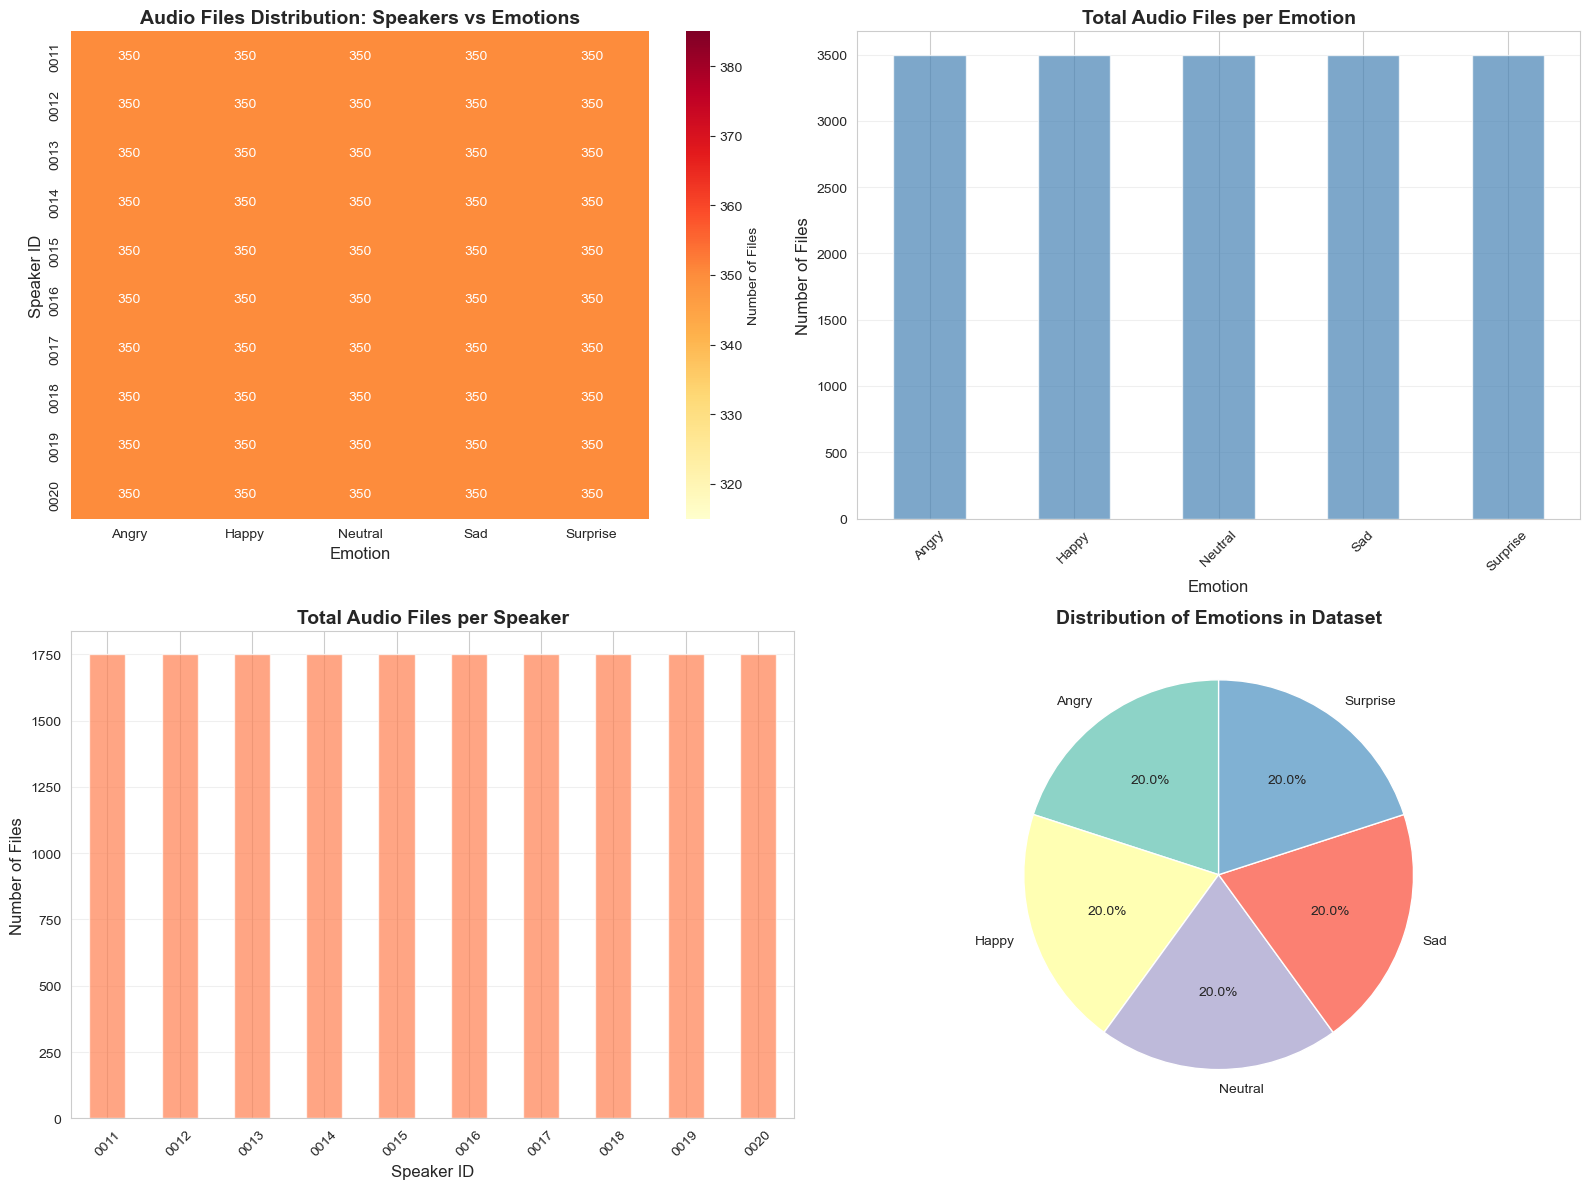


Dataset Balance:
Max files per emotion: 3500
Min files per emotion: 3500
Emotion imbalance ratio: 1.00x


In [6]:
# Create pivot table for heatmap
pivot_counts = df_counts.pivot(index='speaker_id', columns='emotion', values='count')

# Plot 1: Heatmap of file counts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Heatmap
sns.heatmap(pivot_counts, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0, 0], cbar_kws={'label': 'Number of Files'})
axes[0, 0].set_title('Audio Files Distribution: Speakers vs Emotions', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Emotion', fontsize=12)
axes[0, 0].set_ylabel('Speaker ID', fontsize=12)

# Bar plot: Total per emotion
total_per_emotion.plot(kind='bar', ax=axes[0, 1], color='steelblue', alpha=0.7)
axes[0, 1].set_title('Total Audio Files per Emotion', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Emotion', fontsize=12)
axes[0, 1].set_ylabel('Number of Files', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Bar plot: Total per speaker
total_per_speaker.plot(kind='bar', ax=axes[1, 0], color='coral', alpha=0.7)
axes[1, 0].set_title('Total Audio Files per Speaker', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Speaker ID', fontsize=12)
axes[1, 0].set_ylabel('Number of Files', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Pie chart: Emotion distribution
colors = plt.cm.Set3(range(len(total_per_emotion)))
axes[1, 1].pie(total_per_emotion.values, labels=total_per_emotion.index, autopct='%1.1f%%', 
               colors=colors, startangle=90)
axes[1, 1].set_title('Distribution of Emotions in Dataset', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nDataset Balance:")
print(f"Max files per emotion: {total_per_emotion.max()}")
print(f"Min files per emotion: {total_per_emotion.min()}")
print(f"Emotion imbalance ratio: {total_per_emotion.max() / total_per_emotion.min():.2f}x")

## 5. Text Transcription Analysis

In [7]:
# Analyze transcription lengths
if len(df_transcriptions) > 0:
    df_transcriptions['text_length'] = df_transcriptions['transcription'].str.len()
    df_transcriptions['word_count'] = df_transcriptions['transcription'].str.split().str.len()
    
    print("="*60)
    print("TRANSCRIPTION STATISTICS")
    print("="*60)
    
    print(f"\nCharacter Length Statistics:")
    print(df_transcriptions['text_length'].describe())
    
    print(f"\nWord Count Statistics:")
    print(df_transcriptions['word_count'].describe())
    
    print(f"\nAverage statistics by emotion:")
    emotion_text_stats = df_transcriptions.groupby('emotion').agg({
        'text_length': ['mean', 'std'],
        'word_count': ['mean', 'std']
    }).round(2)
    print(emotion_text_stats)

TRANSCRIPTION STATISTICS

Character Length Statistics:
count    17500.000000
mean        31.008057
std          8.937439
min         12.000000
25%         25.000000
50%         29.000000
75%         36.000000
max         63.000000
Name: text_length, dtype: float64

Word Count Statistics:
count    17500.000000
mean         6.289714
std          1.722558
min          2.000000
25%          5.000000
50%          6.000000
75%          7.000000
max         12.000000
Name: word_count, dtype: float64

Average statistics by emotion:
         text_length       word_count      
                mean   std       mean   std
emotion                                    
Angry          31.01  8.94       6.29  1.72
Happy          31.00  8.94       6.29  1.72
Neutral        31.01  8.94       6.29  1.72
Sad            31.01  8.95       6.29  1.72
Surprise       31.01  8.93       6.29  1.72


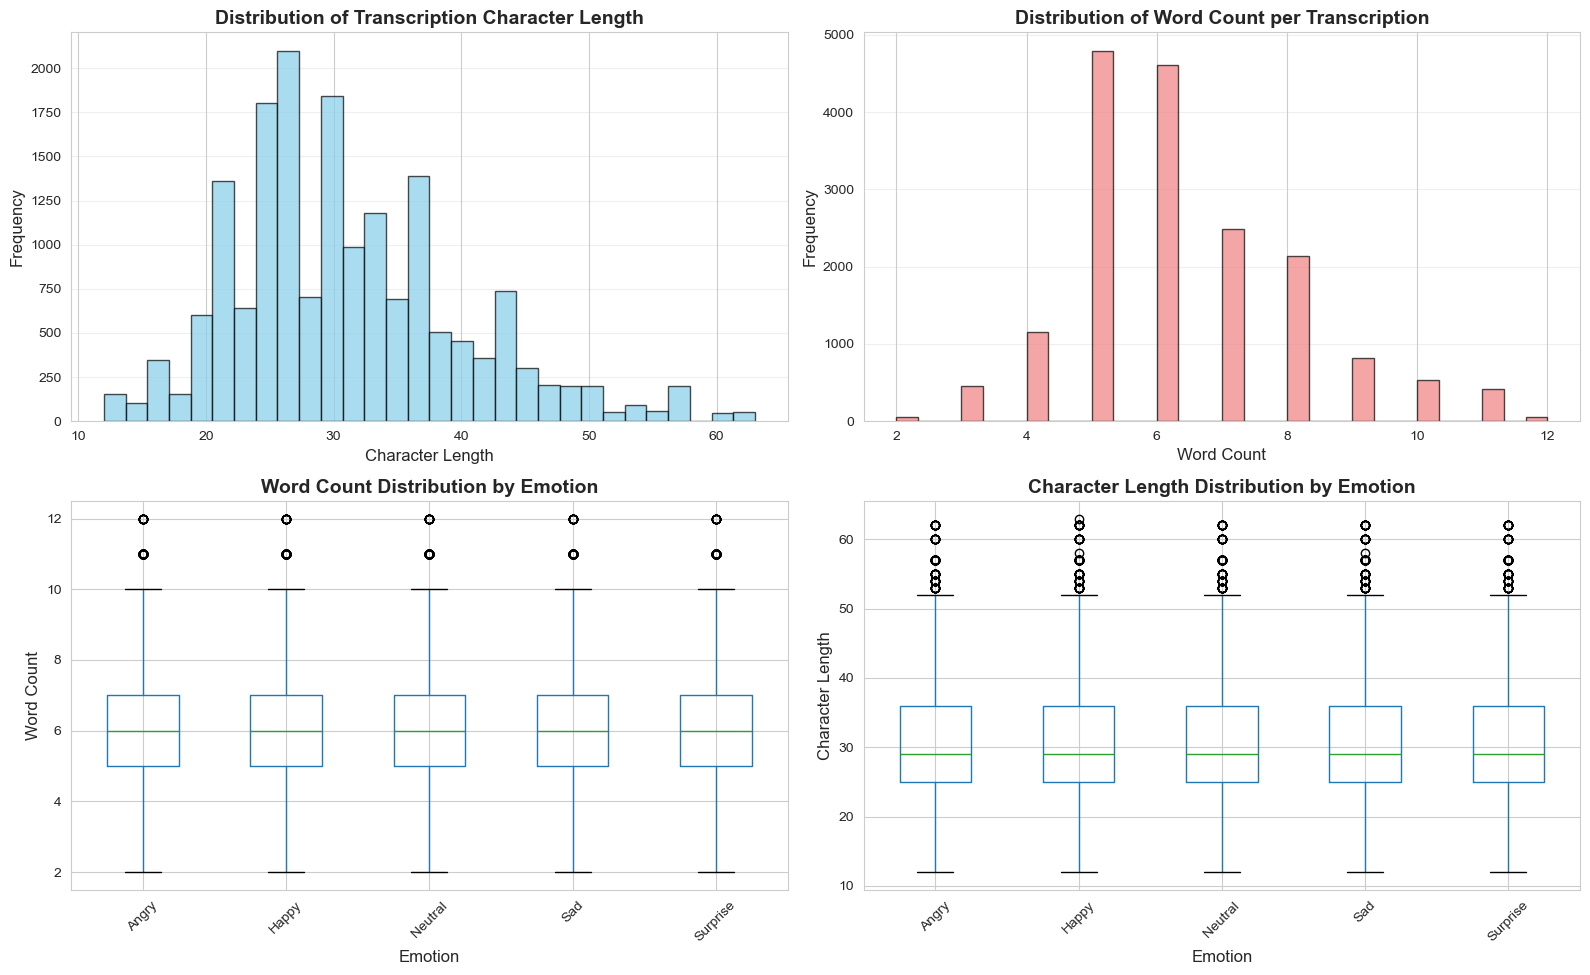

In [8]:
# Visualize transcription statistics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Distribution of text lengths
axes[0, 0].hist(df_transcriptions['text_length'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Transcription Character Length', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Character Length', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].grid(axis='y', alpha=0.3)

# Distribution of word counts
axes[0, 1].hist(df_transcriptions['word_count'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution of Word Count per Transcription', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Word Count', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].grid(axis='y', alpha=0.3)

# Box plot: Word count by emotion
df_transcriptions.boxplot(column='word_count', by='emotion', ax=axes[1, 0])
axes[1, 0].set_title('Word Count Distribution by Emotion', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Emotion', fontsize=12)
axes[1, 0].set_ylabel('Word Count', fontsize=12)
plt.sca(axes[1, 0])
plt.xticks(rotation=45)

# Box plot: Character length by emotion
df_transcriptions.boxplot(column='text_length', by='emotion', ax=axes[1, 1])
axes[1, 1].set_title('Character Length Distribution by Emotion', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Emotion', fontsize=12)
axes[1, 1].set_ylabel('Character Length', fontsize=12)
plt.sca(axes[1, 1])
plt.xticks(rotation=45)

plt.suptitle('')  # Remove the automatic title
plt.tight_layout()
plt.show()

In [9]:
# Vocabulary analysis
print("="*60)
print("VOCABULARY ANALYSIS")
print("="*60)

# Extract all words
all_words = ' '.join(df_transcriptions['transcription'].values).lower().split()
unique_words = set(all_words)

print(f"\nTotal words (tokens): {len(all_words):,}")
print(f"Unique words (vocabulary size): {len(unique_words):,}")
print(f"Lexical diversity: {len(unique_words)/len(all_words):.4f}")

# Most common words
from collections import Counter
word_freq = Counter(all_words)
most_common = word_freq.most_common(20)

print(f"\n20 Most Common Words:")
for word, count in most_common:
    print(f"  {word:.<20} {count:>5}")

VOCABULARY ANALYSIS

Total words (tokens): 110,070
Unique words (vocabulary size): 1,089
Lexical diversity: 0.0099

20 Most Common Words:
  the.................  4817
  a...................  3845
  i...................  3300
  and.................  2297
  to..................  1798
  you.................  1747
  is..................  1472
  of..................  1379
  my..................   851
  he..................   851
  it..................   850
  she.................   850
  that................   818
  are.................   803
  in..................   773
  they................   750
  this................   700
  your................   700
  we..................   698
  not.................   650


## 6. Audio Analysis (Sample)

Analyzing audio characteristics from a sample of files across all speakers and emotions.

In [10]:
# Sample audio files for analysis
def sample_audio_files(n_per_emotion=5):
    """Sample n audio files per emotion for analysis"""
    samples = []
    
    for speaker_id in speaker_ids[:2]:  # Sample from first 2 speakers for faster processing
        for emotion in emotions:
            emotion_folder = dataset_path / speaker_id / emotion
            if emotion_folder.exists():
                wav_files = list(emotion_folder.glob("*.wav"))
                sampled = np.random.choice(wav_files, min(n_per_emotion, len(wav_files)), replace=False)
                for wav_file in sampled:
                    samples.append({
                        'file_path': wav_file,
                        'speaker_id': speaker_id,
                        'emotion': emotion
                    })
    
    return samples

print("Sampling audio files for detailed analysis...")
audio_samples = sample_audio_files(n_per_emotion=5)
print(f"Total sampled files: {len(audio_samples)}")

Sampling audio files for detailed analysis...
Total sampled files: 50


In [11]:
# Analyze audio characteristics
def analyze_audio(file_path):
    """Extract audio characteristics"""
    try:
        y, sr = librosa.load(file_path, sr=None)
        duration = librosa.get_duration(y=y, sr=sr)
        
        # Extract features
        rms = librosa.feature.rms(y=y)[0]
        energy = np.sum(y**2) / len(y)
        zcr = librosa.feature.zero_crossing_rate(y)[0]
        
        return {
            'duration': duration,
            'sample_rate': sr,
            'samples': len(y),
            'rms_mean': np.mean(rms),
            'rms_std': np.std(rms),
            'energy': energy,
            'zcr_mean': np.mean(zcr),
            'zcr_std': np.std(zcr)
        }
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

print("Analyzing audio characteristics (this may take a minute)...")
audio_features = []

for sample in audio_samples:
    features = analyze_audio(sample['file_path'])
    if features:
        features.update({
            'speaker_id': sample['speaker_id'],
            'emotion': sample['emotion']
        })
        audio_features.append(features)

df_audio = pd.DataFrame(audio_features)
print(f"Successfully analyzed {len(df_audio)} audio files")

Analyzing audio characteristics (this may take a minute)...


Successfully analyzed 50 audio files


In [12]:
# Audio statistics
print("="*60)
print("AUDIO CHARACTERISTICS STATISTICS")
print("="*60)

print(f"\nDuration Statistics (seconds):")
print(df_audio['duration'].describe())

print(f"\nSample Rate Statistics:")
print(df_audio['sample_rate'].value_counts())

print(f"\nAverage Duration by Emotion:")
print(df_audio.groupby('emotion')['duration'].agg(['mean', 'std', 'min', 'max']).round(3))

AUDIO CHARACTERISTICS STATISTICS

Duration Statistics (seconds):
count    50.000000
mean      2.695088
std       0.647341
min       1.615000
25%       2.198750
50%       2.633000
75%       3.138781
max       4.415000
Name: duration, dtype: float64

Sample Rate Statistics:
sample_rate
16000    50
Name: count, dtype: int64

Average Duration by Emotion:
           mean    std    min    max
emotion                             
Angry     2.764  0.593  1.757  3.601
Happy     2.749  0.675  1.946  3.792
Neutral   2.209  0.402  1.719  3.080
Sad       2.631  0.685  1.615  3.632
Surprise  3.123  0.605  2.304  4.415


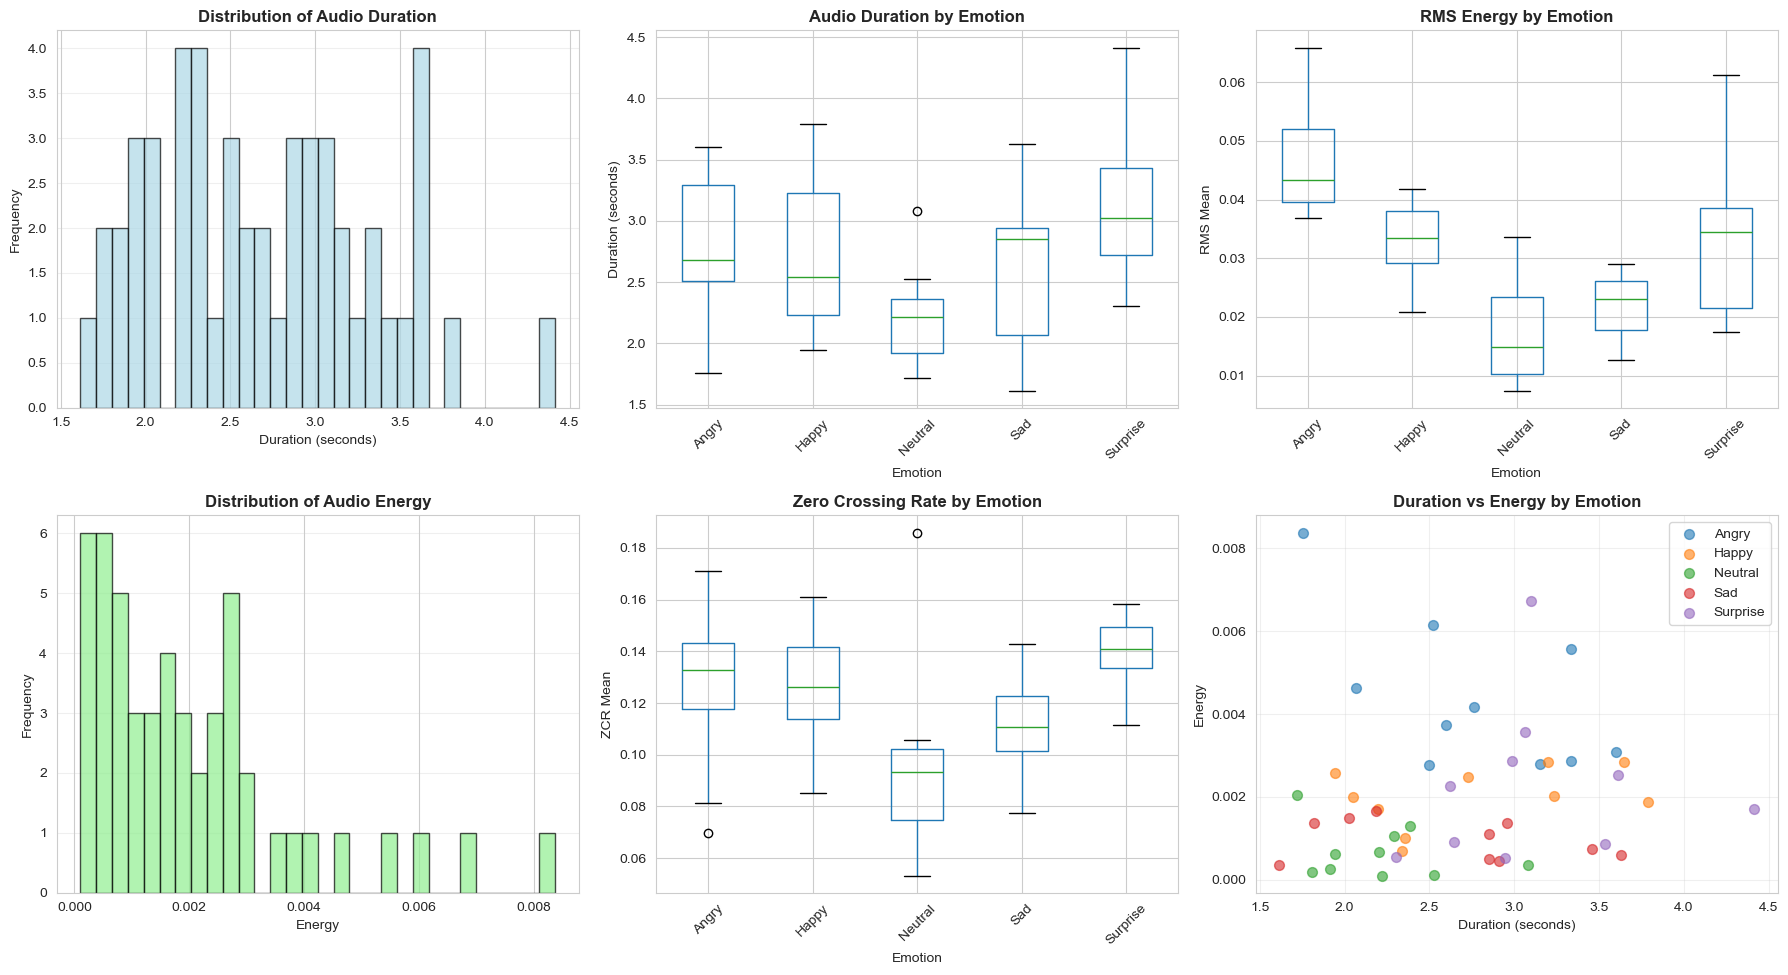

In [13]:
# Visualize audio characteristics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Duration distribution
axes[0, 0].hist(df_audio['duration'], bins=30, color='lightblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Audio Duration', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Duration (seconds)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(axis='y', alpha=0.3)

# Duration by emotion
df_audio.boxplot(column='duration', by='emotion', ax=axes[0, 1])
axes[0, 1].set_title('Audio Duration by Emotion', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Emotion')
axes[0, 1].set_ylabel('Duration (seconds)')
plt.sca(axes[0, 1])
plt.xticks(rotation=45)

# RMS Energy by emotion
df_audio.boxplot(column='rms_mean', by='emotion', ax=axes[0, 2])
axes[0, 2].set_title('RMS Energy by Emotion', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Emotion')
axes[0, 2].set_ylabel('RMS Mean')
plt.sca(axes[0, 2])
plt.xticks(rotation=45)

# Energy distribution
axes[1, 0].hist(df_audio['energy'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribution of Audio Energy', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Energy')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(axis='y', alpha=0.3)

# Zero Crossing Rate by emotion
df_audio.boxplot(column='zcr_mean', by='emotion', ax=axes[1, 1])
axes[1, 1].set_title('Zero Crossing Rate by Emotion', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Emotion')
axes[1, 1].set_ylabel('ZCR Mean')
plt.sca(axes[1, 1])
plt.xticks(rotation=45)

# Scatter: Duration vs Energy by emotion
for emotion in emotions:
    emotion_data = df_audio[df_audio['emotion'] == emotion]
    axes[1, 2].scatter(emotion_data['duration'], emotion_data['energy'], 
                       label=emotion, alpha=0.6, s=50)
axes[1, 2].set_title('Duration vs Energy by Emotion', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Duration (seconds)')
axes[1, 2].set_ylabel('Energy')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.suptitle('')  # Remove automatic title
plt.tight_layout()
plt.show()

## 7. Sample Waveform and Spectrogram Visualization

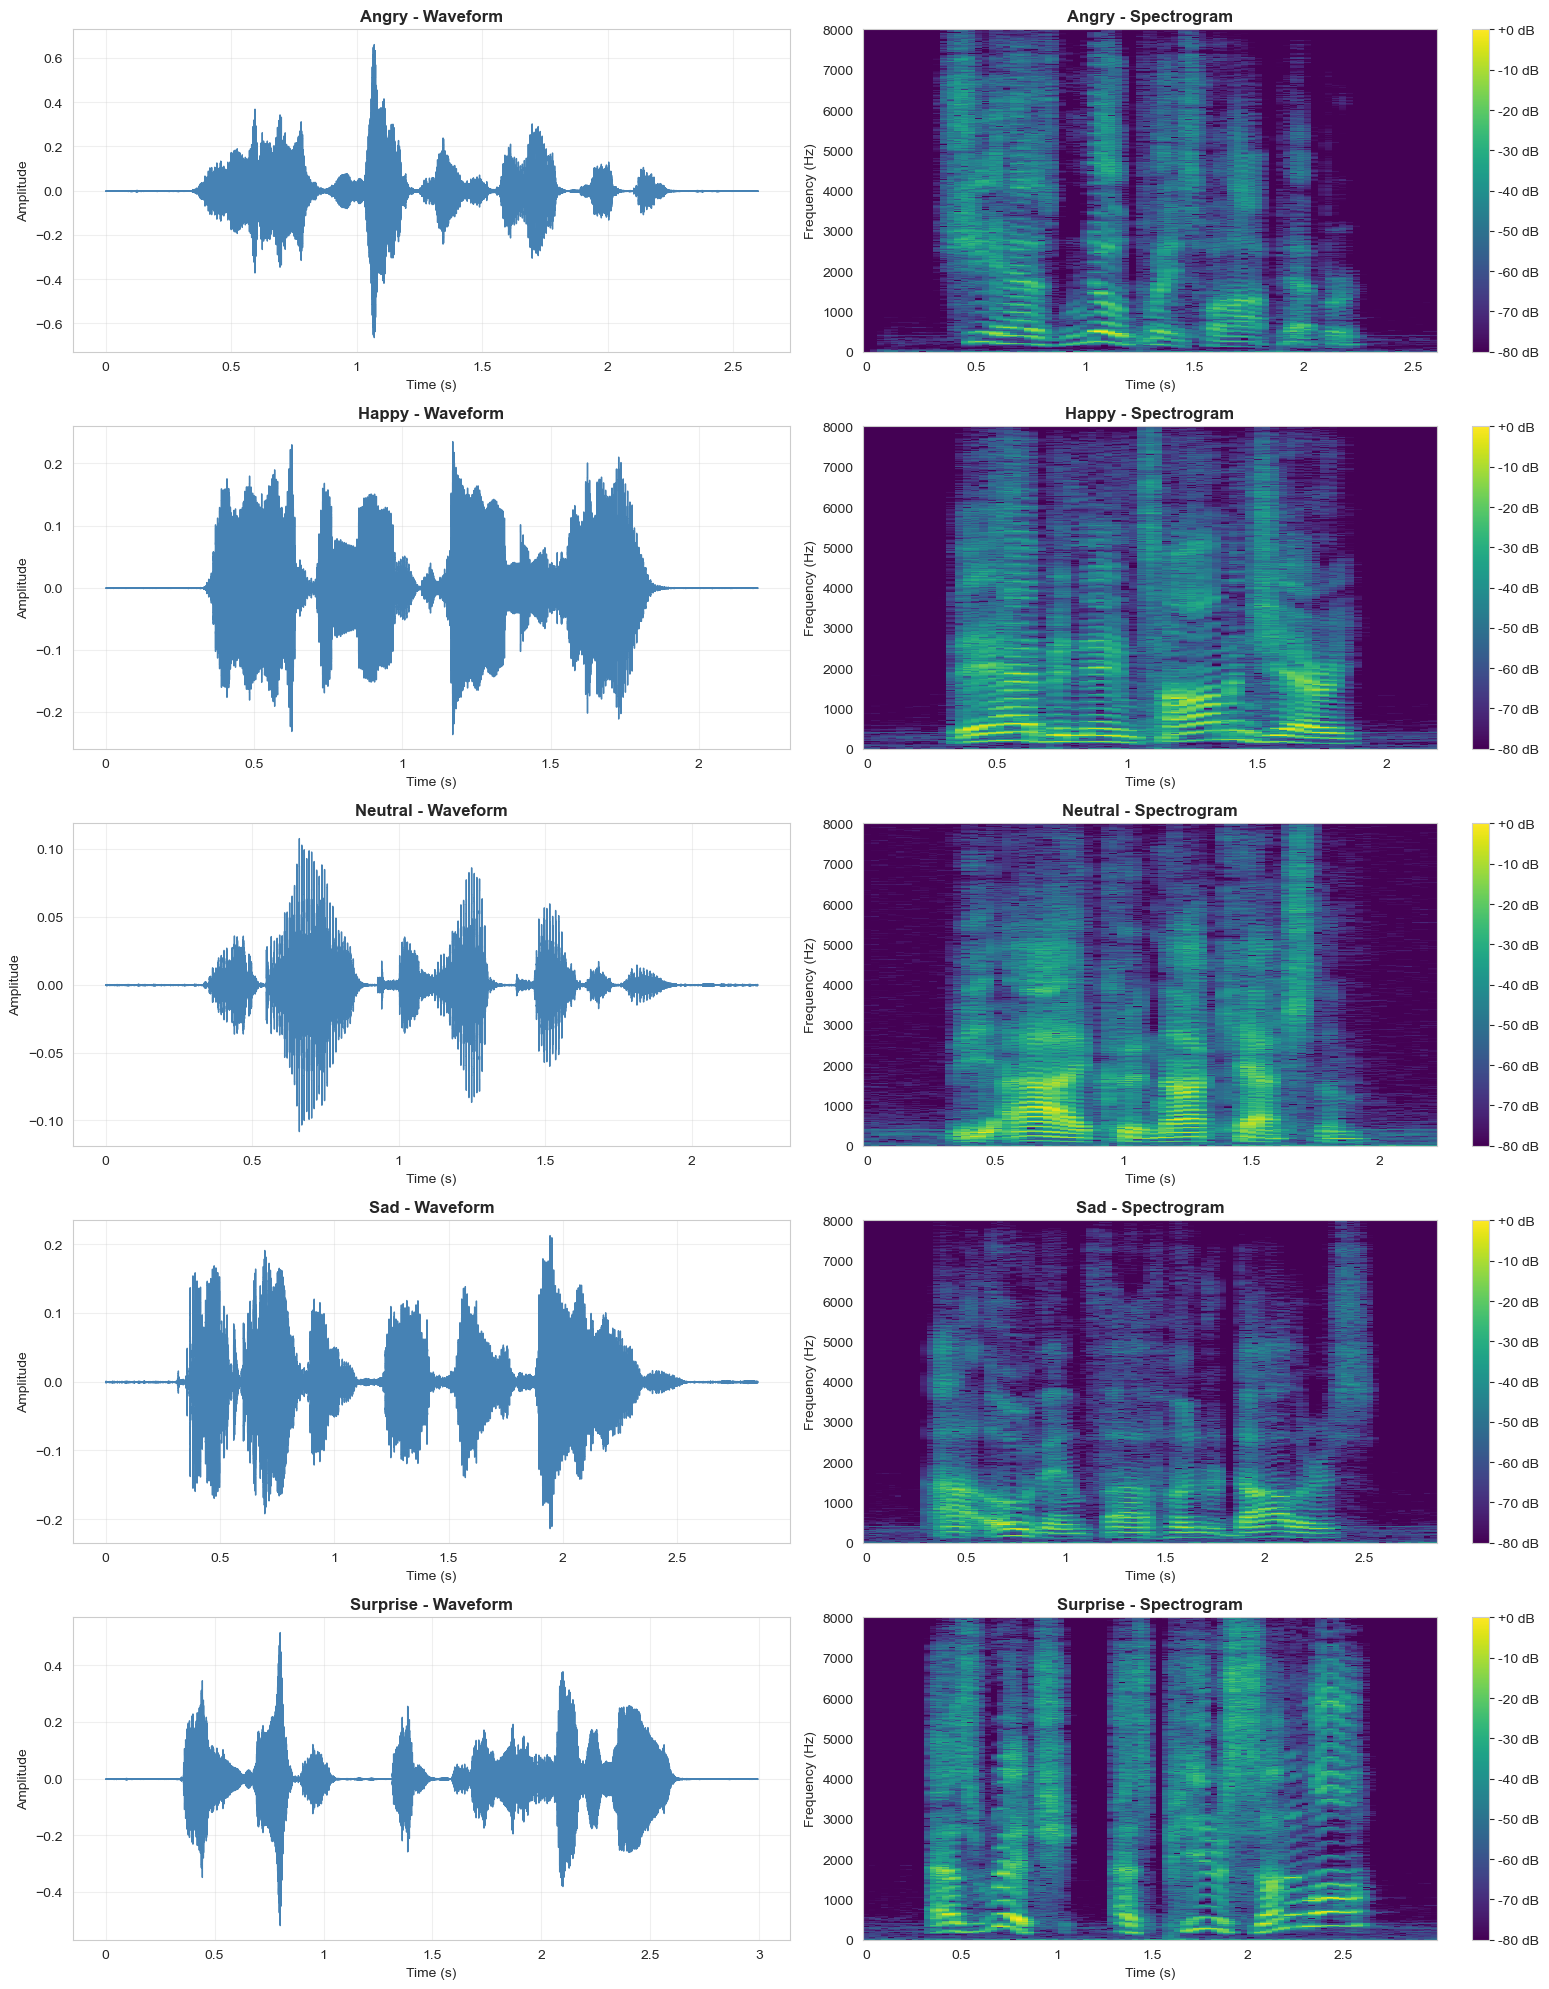

In [14]:
# Visualize sample audio files (one per emotion)
fig, axes = plt.subplots(5, 2, figsize=(16, 20))

for idx, emotion in enumerate(emotions):
    # Get a sample file for this emotion
    emotion_samples = [s for s in audio_samples if s['emotion'] == emotion]
    if emotion_samples:
        sample_file = emotion_samples[0]['file_path']
        
        # Load audio
        y, sr = librosa.load(sample_file, sr=None)
        
        # Waveform
        librosa.display.waveshow(y, sr=sr, ax=axes[idx, 0], color='steelblue')
        axes[idx, 0].set_title(f'{emotion} - Waveform', fontsize=12, fontweight='bold')
        axes[idx, 0].set_xlabel('Time (s)')
        axes[idx, 0].set_ylabel('Amplitude')
        axes[idx, 0].grid(alpha=0.3)
        
        # Spectrogram
        D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
        img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[idx, 1], cmap='viridis')
        axes[idx, 1].set_title(f'{emotion} - Spectrogram', fontsize=12, fontweight='bold')
        axes[idx, 1].set_xlabel('Time (s)')
        axes[idx, 1].set_ylabel('Frequency (Hz)')
        fig.colorbar(img, ax=axes[idx, 1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

## 8. Summary and Key Findings

In [15]:
# Generate summary report
print("="*70)
print(" "*20 + "EDA SUMMARY REPORT")
print("="*70)

print(f"\n{'DATASET OVERVIEW':-^70}")
print(f"  Dataset Path: {dataset_path}")
print(f"  Speakers: {len(speaker_ids)} ({speaker_ids[0]} to {speaker_ids[-1]})")
print(f"  Emotions: {len(emotions)} ({', '.join(emotions)})")
print(f"  Total Audio Files: {df_counts['count'].sum():,}")

print(f"\n{'DISTRIBUTION BY EMOTION':-^70}")
for emotion, count in total_per_emotion.items():
    percentage = (count / df_counts['count'].sum()) * 100
    print(f"  {emotion:<12} {count:>6,} files  ({percentage:>5.2f}%)")

print(f"\n{'DISTRIBUTION BY SPEAKER':-^70}")
for speaker, count in total_per_speaker.items():
    percentage = (count / df_counts['count'].sum()) * 100
    print(f"  Speaker {speaker}  {count:>6,} files  ({percentage:>5.2f}%)")

if len(df_transcriptions) > 0:
    print(f"\n{'TRANSCRIPTION STATISTICS':-^70}")
    print(f"  Total Transcriptions: {len(df_transcriptions):,}")
    print(f"  Vocabulary Size: {len(unique_words):,} unique words")
    print(f"  Average Text Length: {df_transcriptions['text_length'].mean():.1f} characters")
    print(f"  Average Word Count: {df_transcriptions['word_count'].mean():.1f} words")

if len(df_audio) > 0:
    print(f"\n{'AUDIO CHARACTERISTICS (SAMPLED)':-^70}")
    print(f"  Sample Size: {len(df_audio)} files")
    print(f"  Average Duration: {df_audio['duration'].mean():.2f} ± {df_audio['duration'].std():.2f} seconds")
    print(f"  Duration Range: {df_audio['duration'].min():.2f} - {df_audio['duration'].max():.2f} seconds")
    print(f"  Sample Rate: {df_audio['sample_rate'].mode()[0]} Hz (most common)")

print(f"\n{'KEY FINDINGS':-^70}")
if total_per_emotion.max() / total_per_emotion.min() > 2:
    print(f"  ⚠ Emotion Imbalance: {total_per_emotion.max() / total_per_emotion.min():.2f}x difference")
    print(f"    Most frequent: {total_per_emotion.idxmax()} ({total_per_emotion.max()} files)")
    print(f"    Least frequent: {total_per_emotion.idxmin()} ({total_per_emotion.min()} files)")
else:
    print(f"  ✓ Emotions are relatively balanced")

if total_per_speaker.max() / total_per_speaker.min() > 2:
    print(f"  ⚠ Speaker Imbalance: {total_per_speaker.max() / total_per_speaker.min():.2f}x difference")
else:
    print(f"  ✓ Speakers are relatively balanced")

print(f"  ✓ Dataset contains multi-speaker emotional speech data")
print(f"  ✓ Suitable for emotion recognition and TTS tasks")

print("\n" + "="*70)
print("EDA Complete!")
print("="*70)

                    EDA SUMMARY REPORT

---------------------------DATASET OVERVIEW---------------------------
  Dataset Path: ../datasets/Emotion Speech Dataset
  Speakers: 10 (0011 to 0020)
  Emotions: 5 (Angry, Happy, Neutral, Sad, Surprise)
  Total Audio Files: 17,500

-----------------------DISTRIBUTION BY EMOTION------------------------
  Angry         3,500 files  (20.00%)
  Happy         3,500 files  (20.00%)
  Neutral       3,500 files  (20.00%)
  Sad           3,500 files  (20.00%)
  Surprise      3,500 files  (20.00%)

-----------------------DISTRIBUTION BY SPEAKER------------------------
  Speaker 0011   1,750 files  (10.00%)
  Speaker 0012   1,750 files  (10.00%)
  Speaker 0013   1,750 files  (10.00%)
  Speaker 0014   1,750 files  (10.00%)
  Speaker 0015   1,750 files  (10.00%)
  Speaker 0016   1,750 files  (10.00%)
  Speaker 0017   1,750 files  (10.00%)
  Speaker 0018   1,750 files  (10.00%)
  Speaker 0019   1,750 files  (10.00%)
  Speaker 0020   1,750 files  (10.00%)

--